In [1]:
# Uncomment below if not already installed
!pip install transformers datasets nltk timm evaluate

import os
import torch
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from datasets import load_dataset
from transformers import BlipProcessor, BlipForConditionalGeneration
from nltk.translate.bleu_score import sentence_bleu
from tqdm import tqdm


2026-01-02 04:30:40.705308: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-01-02 04:30:40.705337: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-01-02 04:30:40.706278: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-01-02 04:30:40.711159: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-02 04:30:41.379105: W tensorflow/compiler/tf2

In [2]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
torch.manual_seed(SEED)

In [3]:
df_uc = pd.read_csv("./metadata.csv")
df_uc = df_uc[df_uc['source'] == 'Ulcerative Colitis']
print(f"Total UC QA pairs: {len(df_uc):,}")
df_uc.head()

Total UC QA pairs: 16,890


,source,question,answer,img_id
0,Ulcerative Colitis,Are there any abnormalities in the image? Chec...,ulcerative colitis,cla820gl0s3nv071u4fgd7xgq
1,Ulcerative Colitis,Are there any anatomical landmarks in the imag...,none,cla820gl0s3nv071u4fgd7xgq
2,Ulcerative Colitis,Are there any instruments in the image? Check ...,none,cla820gl0s3nv071u4fgd7xgq
3,Ulcerative Colitis,Have all polyps been removed?,not relevant,cla820gl0s3nv071u4fgd7xgq
4,Ulcerative Colitis,Is this finding easy to detect?,yes,cla820gl0s3nv071u4fgd7xgq


In [4]:
from transformers import BlipProcessor, BlipForConditionalGeneration

processor_blip = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model_blip = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-vqa-base").to(DEVICE)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [5]:
def get_blip_answer(image_path, question):
    image = Image.open(image_path).convert("RGB")
    inputs = processor_blip(image, question, return_tensors="pt").to(DEVICE)
    output = model_blip.generate(**inputs)
    return processor_blip.decode(output[0], skip_special_tokens=True)

In [6]:
# Original single-sample CPU-ish loop (commented out)
# from nltk.translate.bleu_score import sentence_bleu
# 
# # Use full UC subset (loop below skips rows with missing images)
# sample_df = df_uc
# results = []
# 
# for _, row in tqdm(sample_df.iterrows(), total=len(sample_df)):
#     img_id, question, gt_answer = row['img_id'], row['question'], row['answer']
#     img_path = f"./images/{img_id}.jpg"
#     if not os.path.exists(img_path):
#         continue
#     try:
#         pred = get_blip_answer(img_path, question)
#         bleu = sentence_bleu([gt_answer.split()], pred.split())
#         results.append((img_id, question, gt_answer, pred, bleu))
#     except Exception as e:
#         print(f"Error with {img_id}: {e}")
#         continue
# 
# results_df = pd.DataFrame(results, columns=["img_id", "question", "ground_truth", "predicted", "bleu"])
# results_df.to_csv("blip_uc_results.csv", index=False)
# results_df.head()

# GPU-aware batched BLIP inference (keeps rows with on-disk images)
import os
import torch
from nltk.translate.bleu_score import sentence_bleu
from PIL import Image
from tqdm import tqdm

# Speed/quality knobs (tune for your GPU)
BATCH_SIZE = 128        # raise for more throughput if VRAM allows
MAX_NEW_TOKENS = 8     # shorter generations -> faster; increase if answers truncate
USE_FP16 = True        # set False if you see dtype errors

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE != "cuda":
    print("⚠️ CUDA not available; running on CPU. Check drivers/CUDA if this is unexpected.")

# Avoid right-padding warning; aligns with decoder-only generation
processor_blip.tokenizer.padding_side = "left"
if processor_blip.tokenizer.pad_token_id is None:
    processor_blip.tokenizer.pad_token_id = processor_blip.tokenizer.eos_token_id
model_blip.config.pad_token_id = processor_blip.tokenizer.pad_token_id

model_blip = model_blip.to(DEVICE)
if USE_FP16 and DEVICE == "cuda":
    model_blip = model_blip.half()
model_blip.eval()
# torch.set_grad_enabled(False)  # commented to avoid disabling grads for later training cells

rows = []
for _, row in df_uc.iterrows():
    img_path = f"./images/{row['img_id']}.jpg"
    if os.path.exists(img_path):
        rows.append((row['img_id'], img_path, row['question'], row['answer']))

results = []
for i in tqdm(range(0, len(rows), BATCH_SIZE)):
    chunk = rows[i:i + BATCH_SIZE]
    images = [Image.open(p).convert("RGB") for _, p, _, _ in chunk]
    questions = [q for _, _, q, _ in chunk]

    inputs = processor_blip(
        images=images,
        text=questions,
        return_tensors="pt",
        padding=True,
    ).to(DEVICE)
    with torch.inference_mode():
        outputs = model_blip.generate(**inputs, max_new_tokens=MAX_NEW_TOKENS)
    preds = processor_blip.batch_decode(outputs, skip_special_tokens=True)

    for (img_id, img_path, question, gt_answer), pred in zip(chunk, preds):
        bleu = sentence_bleu([str(gt_answer).split()], str(pred).split())
        results.append((img_id, question, gt_answer, pred, bleu))

results_df = pd.DataFrame(results, columns=["img_id", "question", "ground_truth", "predicted", "bleu"])
results_df.to_csv("blip_uc_results.csv", index=False)
results_df.head()


 30%|██▉       | 39/132 [01:09<02:38,  1.70s/it]/home/arcturus/miniforge3/envs/vqa-rag/lib/python3.11/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 2-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/home/arcturus/miniforge3/envs/vqa-rag/lib/python3.11/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 3-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of
how many N-gram overlaps of lower order it contains.
Consider using lower n-gram order or use SmoothingFunction()
  warnings.warn(_msg)
/home/arcturus/miniforge3/envs/vqa-rag/lib/python3.11/site-packages/nltk/translate/bleu_score.py:577: UserWarning: 
The hypothesis contains 0 counts of 4-gram overlaps.
Therefore the BLEU score evaluates to 0, independently of

,img_id,question,ground_truth,predicted,bleu
0,cla820gl0s3nv071u4fgd7xgq,Are there any abnormalities in the image? Chec...,ulcerative colitis,are there any abnormalities in the image? chec...,0.0
1,cla820gl0s3nv071u4fgd7xgq,Are there any anatomical landmarks in the imag...,none,are there any anatomical landmarks in the imag...,0.0
2,cla820gl0s3nv071u4fgd7xgq,Are there any instruments in the image? Check ...,none,are there any instruments in the image? check ...,0.0
3,cla820gl0s3nv071u4fgd7xgq,Have all polyps been removed?,not relevant,have all polyps been removed?,0.0
4,cla820gl0s3nv071u4fgd7xgq,Is this finding easy to detect?,yes,is this finding easy to detect?,0.0


In [7]:
# In[57]: REPLACE THIS ENTIRE CELL

import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from tqdm import tqdm
import pandas as pd
import time
import os

# --- CONFIGURATION ---
BASE_BATCH_SIZE = 128    # If this runs OOM, lower to 64
NUM_WORKERS = 16         # Ryzen 5950X optimization
USE_FP16 = True
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# --- 1. Generic Dataset Class ---
class VQAEvalDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Handle potentially missing 'img_path' column
        if "img_path" in row:
            path = row["img_path"]
        else:
            path = f"./images/{row['img_id']}.jpg"
            
        try:
            image = Image.open(path).convert("RGB")
            return {
                "image": image,
                "question": str(row['question']),
                "answer": str(row['answer']),
                "img_id": row['img_id'],
                "img_path": path,
                "valid": True
            }
        except Exception:
            return {"valid": False}

# --- 2. Dynamic Collator ---
class ModelCollator:
    def __init__(self, processor, model_cfg):
        self.processor = processor
        self.cfg = model_cfg
    
    def __call__(self, batch):
        # Remove invalid images from batch
        batch = [x for x in batch if x["valid"]]
        if not batch: return None
        
        images = [x['image'] for x in batch]
        raw_qs = [x['question'] for x in batch]
        answers = [x['answer'] for x in batch]
        ids = [x['img_id'] for x in batch]
        paths = [x['img_path'] for x in batch]

        # Handle prompts for GIT
        text_inputs = raw_qs
        if self.cfg.get("task") == "generative_vqa_prompt":
            template = self.cfg.get("prompt_template", "Question: {q}\nAnswer:")
            text_inputs = [template.format(q=q) for q in raw_qs]

        # Tokenize entire batch at once
        inputs = self.processor(images=images, text=text_inputs, return_tensors="pt", padding=True)
        return inputs, answers, ids, paths, raw_qs

# --- 3. Execution Function ---
def evaluate_models_on_sample(model_keys, sample_df, out_dir="phase3_results"):
    os.makedirs(out_dir, exist_ok=True)
    summary_rows = []
    per_model_frames = []
    
    dataset = VQAEvalDataset(sample_df)

    for key in model_keys:
        # Dynamic Batch Sizing: Lower for BLIP-2 to prevent crashing
        if "blip2" in key:
            current_batch_size = 32 
        else:
            current_batch_size = BASE_BATCH_SIZE
            
        print(f"\n=== Evaluating {key} (Batch Size: {current_batch_size}) ===")
        start_time = time.time()
        
        # Load Model
        if key not in MODEL_CONFIGS:
             raise ValueError(f"Model {key} not found. Run cell defining MODEL_CONFIGS first.")
        
        cfg = MODEL_CONFIGS[key]
        processor, model = load_model(key)
        model = model.to(DEVICE)
        if USE_FP16: model = model.half()
        model.eval()

        collator = ModelCollator(processor, cfg)
        loader = DataLoader(
            dataset, 
            batch_size=current_batch_size, 
            num_workers=NUM_WORKERS, 
            collate_fn=collator, 
            pin_memory=True
        )

        preds, refs, rows = [], [], []
        
        # BATCHED LOOP
        with torch.no_grad():
            for batch in tqdm(loader):
                if batch is None: continue
                
                inputs, gt_answers, img_ids, img_paths, questions = batch
                
                # Move to GPU
                inputs = {k: v.to(DEVICE) for k, v in inputs.items()}
                if USE_FP16 and "pixel_values" in inputs:
                    inputs["pixel_values"] = inputs["pixel_values"].half()
                
                task = cfg["task"]
                
                # --- GENERATION (Batched) ---
                if "generative" in task:
                    gen_kwargs = cfg.get("gen_kwargs", {})
                    generated_ids = model.generate(**inputs, **gen_kwargs)
                    batch_preds = processor.batch_decode(generated_ids, skip_special_tokens=True)
                    
                    if task == "generative_vqa_prompt": 
                        batch_preds = [p.split("Answer:")[-1].strip() if "Answer:" in p else p.strip() for p in batch_preds]
                
                elif task == "classifier_vqa":
                    outputs = model(**inputs)
                    logits = outputs.logits
                    pred_indices = torch.argmax(logits, dim=-1).cpu().tolist()
                    batch_preds = [model.config.id2label.get(idx, str(idx)) for idx in pred_indices]
                
                else:
                    batch_preds = ["ERROR"] * len(gt_answers)

                # Store Results
                for i, pred in enumerate(batch_preds):
                    bleu = compute_bleu(pred, gt_answers[i])
                    rows.append({
                        "model": key,
                        "img_id": img_ids[i],
                        "question": questions[i],
                        "ground_truth": gt_answers[i],
                        "predicted": pred,
                        "bleu": bleu,
                        "img_path": img_paths[i]
                    })
                    preds.append(pred)
                    refs.append(gt_answers[i])
        
        elapsed = time.time() - start_time
        df = pd.DataFrame(rows)
        per_model_frames.append(df)
        df.to_csv(os.path.join(out_dir, f"{key}_uc_predictions.csv"), index=False)
        
        rouge = compute_rougeL(preds, refs) if preds else 0.0
        
        summary_rows.append({
            "model": key,
            "n_examples": len(df),
            "BLEU_avg": df["bleu"].mean(),
            "ROUGE_L": rouge,
            "time_sec": elapsed,
            "time_per_example_sec": elapsed / max(1, len(df))
        })
        
        del model, inputs
        torch.cuda.empty_cache()

    summary_df = pd.DataFrame(summary_rows).sort_values(by="BLEU_avg", ascending=False)
    detail_df = pd.concat(per_model_frames, ignore_index=True) if per_model_frames else pd.DataFrame()
    summary_df.to_csv(os.path.join(out_dir, "summary_uc_phase3.csv"), index=False)
    
    return summary_df, detail_df

In [8]:
# !pip install -q transformers datasets timm evaluate nltk sentencepiece accelerate

import os
import math
import json
import time
import torch
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

import evaluate

# Make sure NLTK has the required data
import nltk
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt")


In [9]:
import os
import pandas as pd

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42
torch.manual_seed(SEED)

print("Using device:", DEVICE)

# Ensure df_uc and available_df exist
if 'df_uc' not in globals():
    df_uc = pd.read_csv('./metadata.csv')
    if 'source' in df_uc.columns:
        df_uc = df_uc[df_uc['source'] == 'Ulcerative Colitis']
    df_uc = df_uc.reset_index(drop=True)

if 'available_df' not in globals():
    df_uc = df_uc.copy()
    if 'img_path' not in df_uc.columns:
        df_uc['img_path'] = df_uc['img_id'].astype(str).apply(lambda x: f'./images/{x}.jpg')
    available_df = df_uc[df_uc['img_path'].apply(os.path.exists)].reset_index(drop=True)

def get_uc_sample(available_df, n_samples=None, seed=SEED):
    if n_samples is None:
        return available_df.reset_index(drop=True)
    n = min(n_samples, len(available_df))
    return available_df.sample(n, random_state=seed).reset_index(drop=True)

sample_df = get_uc_sample(available_df, n_samples=None)
len(sample_df), sample_df.head(2)


Using device: cuda


(16890,
                source                                           question  \
 0  Ulcerative Colitis  Are there any abnormalities in the image? Chec...   
 1  Ulcerative Colitis  Are there any anatomical landmarks in the imag...   
 
                answer                     img_id  \
 0  ulcerative colitis  cla820gl0s3nv071u4fgd7xgq   
 1                none  cla820gl0s3nv071u4fgd7xgq   
 
                                  img_path  
 0  ./images/cla820gl0s3nv071u4fgd7xgq.jpg  
 1  ./images/cla820gl0s3nv071u4fgd7xgq.jpg  )

In [10]:
# Unified registry of models and their processors.
# We "lazy load" and cache them the first time they are used.

MODEL_CONFIGS = {
    "blip": {
        "model_name": "Salesforce/blip-vqa-base",
        "processor_cls": ("transformers", "BlipProcessor"),
        "model_cls": ("transformers", "BlipForConditionalGeneration"),
        "task": "generative_vqa",
        "gen_kwargs": {"max_new_tokens": 30},
        "batch_size": 64
    },
    "blip2": {
        "model_name": "Salesforce/blip2-opt-2.7b",
        "processor_cls": ("transformers", "Blip2Processor"),
        "model_cls": ("transformers", "Blip2ForConditionalGeneration"),
        "task": "generative_vqa",
        "gen_kwargs": {"max_new_tokens": 30}
    },
    "git": {
        "model_name": "microsoft/git-base-vqav2",
        "processor_cls": ("transformers", "AutoProcessor"),   # resolves to GitProcessor
        "model_cls": ("transformers", "AutoModelForCausalLM"),# resolves to GitForCausalLM
        "task": "generative_vqa_prompt",                      # we pass a text prompt template
        "prompt_template": "Question: {q}\nAnswer:",
        "gen_kwargs": {"max_new_tokens": 12},                 # shorter generation to save VRAM
        "batch_size": 8                                        # lower batch for VRAM safety
    },
    "vilt": {
        "model_name": "dandelin/vilt-b32-finetuned-vqa",
        "processor_cls": ("transformers", "ViltProcessor"),
        "model_cls": ("transformers", "ViltForQuestionAnswering"),
        "task": "classifier_vqa",  # predicts from a fixed VQA answer vocab
    },
}

_model_cache = {}  # format : {key: {"processor": ..., "model": ...}}

def _import(qualified):
    """Import a class given ('module', 'ClassName') tuple."""
    module_name, cls_name = qualified
    module = __import__(module_name, fromlist=[cls_name])
    return getattr(module, cls_name)

def load_model(key):
    """Lazy-load and cache a model+processor by key."""
    if key in _model_cache:
        return _model_cache[key]["processor"], _model_cache[key]["model"]

    cfg = MODEL_CONFIGS[key]
    proc_cls = _import(cfg["processor_cls"])
    mdl_cls  = _import(cfg["model_cls"])

    processor = proc_cls.from_pretrained(cfg["model_name"])
    model = mdl_cls.from_pretrained(cfg["model_name"])

    model = model.to(DEVICE)
    model.eval()

    _model_cache[key] = {"processor": processor, "model": model}
    return processor, model

In [11]:
@torch.inference_mode()
def get_answer_unified(model_key: str, img_path: str, question: str) -> str:
    """
    Runs VQA using the chosen model. Returns a plain answer string.
    Handles generative (BLIP/BLIP2/GIT) and classifier (ViLT) styles.
    """
    cfg = MODEL_CONFIGS[model_key]
    processor, model = load_model(model_key)
    image = Image.open(img_path).convert("RGB")

    task = cfg["task"]

    if task == "generative_vqa":
        # BLIP / BLIP-2 path
        inputs = processor(image, question, return_tensors="pt").to(DEVICE)
        gen_kwargs = cfg.get("gen_kwargs", {})
        out = model.generate(**inputs, **gen_kwargs)
        ans = processor.decode(out[0], skip_special_tokens=True).strip()
        return ans

    elif task == "generative_vqa_prompt":
        # GIT uses a text prompt convention
        prompt = cfg["prompt_template"].format(q=question)
        inputs = processor(images=image, text=prompt, return_tensors="pt").to(DEVICE)
        gen_kwargs = cfg.get("gen_kwargs", {})
        generated_ids = model.generate(**inputs, **gen_kwargs)
        ans = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]
        # Some GIT checkpoints echo the prompt; trim if present
        if "Answer:" in ans:
            ans = ans.split("Answer:")[-1].strip()
        return ans

    elif task == "classifier_vqa":
        # ViLT returns logits over a fixed answer vocab; select argmax id2label
        inputs = processor(image, question, return_tensors="pt").to(DEVICE)
        outputs = model(**inputs)
        logits = outputs.logits
        idx = int(torch.argmax(logits, dim=-1).item())
        # id2label is attached to model.config in this checkpoint
        label = model.config.id2label.get(idx, str(idx))
        return label

    # elif task == "florence2_vqa":
    #     # Florence-2 typically expects a special VQA tag; left as optional
    #     prompt = f"<VQA>{question}"
    #     inputs = processor(text=prompt, images=image, return_tensors="pt").to(DEVICE)
    #     out = model.generate(**inputs, max_new_tokens=30)
    #     ans = processor.batch_decode(out, skip_special_tokens=True)[0].strip()
    #     return ans

    else:
        raise ValueError(f"Unknown task type: {task}")

In [12]:
# --- Metrics: BLEU (NLTK) + ROUGE-L (HF evaluate if available; otherwise pure-Python LCS) ---

from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
smooth_fn = SmoothingFunction().method1  # smoothing to avoid BLEU=0 for short strings

# BLEU (sentence-level)
def compute_bleu(pred: str, ref: str) -> float:
    ref_tokens = [str(ref).split()]
    pred_tokens = str(pred).split()
    return float(sentence_bleu(ref_tokens, pred_tokens, smoothing_function=smooth_fn))

# Try to use HuggingFace 'evaluate' for ROUGE-L; if unavailable, fall back to pure-Python LCS-based ROUGE-L
_use_hf_rouge = False
try:
    import evaluate as _hf_evaluate
    _rouge_metric = _hf_evaluate.load("rouge")  # may fail if internet is blocked
    _use_hf_rouge = True
except Exception:
    _use_hf_rouge = False

def _lcs_len(a_tokens, b_tokens):
    # classic DP LCS
    n, m = len(a_tokens), len(b_tokens)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(1, n+1):
        ai = a_tokens[i-1]
        for j in range(1, m+1):
            if ai == b_tokens[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[n][m]

def _rougeL_f1_single(pred: str, ref: str) -> float:
    # token-level ROUGE-L F1 (common for short answers)
    p_tokens = str(pred).split()
    r_tokens = str(ref).split()
    if not p_tokens and not r_tokens:
        return 1.0
    if not p_tokens or not r_tokens:
        return 0.0
    lcs = _lcs_len(p_tokens, r_tokens)
    prec = lcs / max(1, len(p_tokens))
    rec  = lcs / max(1, len(r_tokens))
    if prec + rec == 0:
        return 0.0
    f1 = 2 * prec * rec / (prec + rec)
    return float(f1)

def compute_rougeL(preds, refs) -> float:
    """
    Returns dataset-level ROUGE-L:
    - If HF evaluate is available: uses its aggregate (rougeL).
    - Else: mean of token-level ROUGE-L F1 across examples.
    """
    if _use_hf_rouge:
        scores = _rouge_metric.compute(predictions=list(preds), references=list(refs), use_stemmer=True)
        return float(scores.get("rougeL", 0.0))
    else:
        if len(preds) == 0: 
            return 0.0
        vals = [_rougeL_f1_single(p, r) for p, r in zip(preds, refs)]
        return float(sum(vals) / len(vals))

In [13]:
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import time
import pandas as pd

# Batching evaluation for all models using VQAEvalDataset + ModelCollator
# Configure per-model batch sizes here if needed
DEFAULT_BATCH_SIZE = 128


def evaluate_models_on_sample(model_keys, sample_df, out_dir="phase3_results", batch_size=DEFAULT_BATCH_SIZE, isolate_models=True):
    os.makedirs(out_dir, exist_ok=True)
    summary_rows = []
    per_model_frames = []

    # Build dataset once
    dataset = VQAEvalDataset(sample_df)

    for key in model_keys:
        print(f"=== Evaluating {key} ===")
        processor, model = load_model(key)
        cfg = MODEL_CONFIGS[key]
        task = cfg.get("task", "generative_vqa")
        bs = cfg.get("batch_size", batch_size)

        collate = ModelCollator(processor, cfg)
        loader = DataLoader(dataset, batch_size=bs, shuffle=False, num_workers=2, collate_fn=collate)

        preds, refs, rows = [], [], []
        start_time = time.time()

        for batch in tqdm(loader, total=len(loader)):
            if batch is None:
                continue
            inputs, gt_answers, img_ids, img_paths, questions = batch
            inputs = inputs.to(DEVICE)

            if task in ("generative_vqa", "generative_vqa_prompt"):
                with torch.no_grad():
                    outputs = model.generate(**inputs, max_new_tokens=cfg.get("gen_kwargs", {}).get("max_new_tokens", 20))
                batch_preds = processor.batch_decode(outputs, skip_special_tokens=True)
                if task == "generative_vqa_prompt":
                    batch_preds = [p.split("Answer:")[-1].strip() if "Answer:" in p else p.strip() for p in batch_preds]

            elif task == "classifier_vqa":
                with torch.no_grad():
                    logits = model(**inputs).logits
                    pred_indices = torch.argmax(logits, dim=-1).cpu().tolist()
                batch_preds = [model.config.id2label.get(idx, str(idx)) for idx in pred_indices]

            else:
                batch_preds = ["ERROR"] * len(gt_answers)

            for i, pred in enumerate(batch_preds):
                bleu = compute_bleu(pred, gt_answers[i])
                rows.append({
                    "model": key,
                    "img_id": img_ids[i],
                    "question": questions[i],
                    "ground_truth": gt_answers[i],
                    "predicted": pred,
                    "bleu": bleu,
                    "img_path": img_paths[i]
                })
                preds.append(pred)
                refs.append(gt_answers[i])

        elapsed = time.time() - start_time
        df = pd.DataFrame(rows)
        per_model_frames.append(df)
        df.to_csv(os.path.join(out_dir, f"{key}_uc_predictions.csv"), index=False)

        rouge = compute_rougeL(preds, refs) if preds else 0.0
        summary_rows.append({
            "model": key,
            "n_examples": len(df),
            "BLEU_avg": df["bleu"].mean(),
            "ROUGE_L": rouge,
            "time_sec": elapsed,
            "time_per_example_sec": elapsed / max(1, len(df))
        })

        if isolate_models:
            try:
                model.to("cpu")
            except Exception:
                pass
            try:
                if "_model_cache" in globals() and key in _model_cache:
                    del _model_cache[key]
            except Exception:
                pass
            torch.cuda.empty_cache()
        else:
            torch.cuda.empty_cache()

    summary_df = pd.DataFrame(summary_rows).sort_values(by="BLEU_avg", ascending=False)
    detail_df = pd.concat(per_model_frames, ignore_index=True) if per_model_frames else pd.DataFrame()
    summary_df.to_csv(os.path.join(out_dir, "summary_uc_phase3.csv"), index=False)
    return summary_df, detail_df


In [14]:
# Choose which models to run (you can comment out heavy ones like blip2 on small GPUs)
models_to_run = ["blip", "vilt", "git", "blip2"]  # order is up to you

summary_df, detail_df = evaluate_models_on_sample(models_to_run, sample_df)

print("\n=== Summary (higher is better) ===")
display(summary_df)

print("\n=== A few rows from the combined details ===")
display(detail_df.head(8))

=== Evaluating blip ===


  0%|          | 0/264 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.
100%|██████████| 264/264 [04:59<00:00,  1.14s/it]


=== Evaluating vilt ===


  0%|          | 0/132 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
100%|██████████| 132/132 [01:42<00:00,  1.29it/s]


=== Evaluating git ===


...

  0%|          | 0/132 [00:00<?, ?it/s]huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
100%|██████████| 132/132 [14:50<00:00,  6.75s/it]



=== Summary (higher is better) ===


,model,n_examples,BLEU_avg,ROUGE_L,time_sec,time_per_example_sec
1,vilt,16890,0.031478,0.198241,102.277363,0.006055
0,blip,16890,0.000335,0.002885,299.824342,0.017752
3,blip2,16890,0.000007,0.000044,890.774998,0.052740
2,git,16890,0.000004,0.000036,531.309245,0.031457



=== A few rows from the combined details ===


,model,img_id,question,ground_truth,predicted,bleu,img_path
0,blip,cla820gl0s3nv071u4fgd7xgq,Are there any abnormalities in the image? Chec...,ulcerative colitis,are there any abnormalities in the image? chec...,0.0,./images/cla820gl0s3nv071u4fgd7xgq.jpg
1,blip,cla820gl0s3nv071u4fgd7xgq,Are there any anatomical landmarks in the imag...,none,are there any anatomical landmarks in the imag...,0.0,./images/cla820gl0s3nv071u4fgd7xgq.jpg
2,blip,cla820gl0s3nv071u4fgd7xgq,Are there any instruments in the image? Check ...,none,are there any instruments in the image? check ...,0.0,./images/cla820gl0s3nv071u4fgd7xgq.jpg
3,blip,cla820gl0s3nv071u4fgd7xgq,Have all polyps been removed?,not relevant,have all polyps been removed?. 5,0.0,./images/cla820gl0s3nv071u4fgd7xgq.jpg
4,blip,cla820gl0s3nv071u4fgd7xgq,Is this finding easy to detect?,yes,is this finding easy to detect?. 5,0.0,./images/cla820gl0s3nv071u4fgd7xgq.jpg
5,blip,cla820gl0s3nv071u4fgd7xgq,Is there a green/black box artefact?,no,is there a green / black box artefact? bvvvv,0.0,./images/cla820gl0s3nv071u4fgd7xgq.jpg
6,blip,cla820gl0s3nv071u4fgd7xgq,Is there text?,yes,is there text?ing on it,0.0,./images/cla820gl0s3nv071u4fgd7xgq.jpg
7,blip,cla820gl0s3nv071u4fgd7xgq,What type of polyp is present?,none,what type of polyp is present?. 5,0.0,./images/cla820gl0s3nv071u4fgd7xgq.jpg


Text(0, 0.5, 'ROUGE-L')

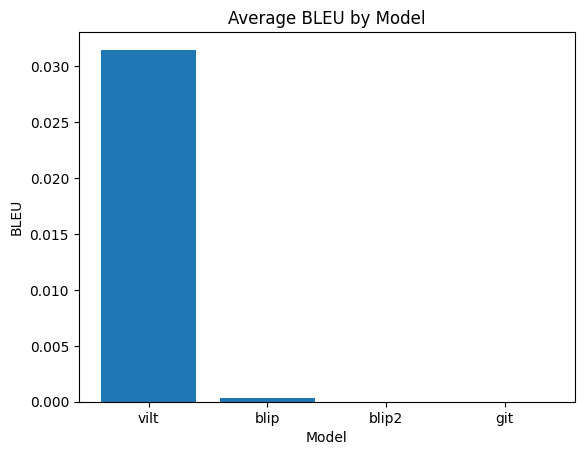

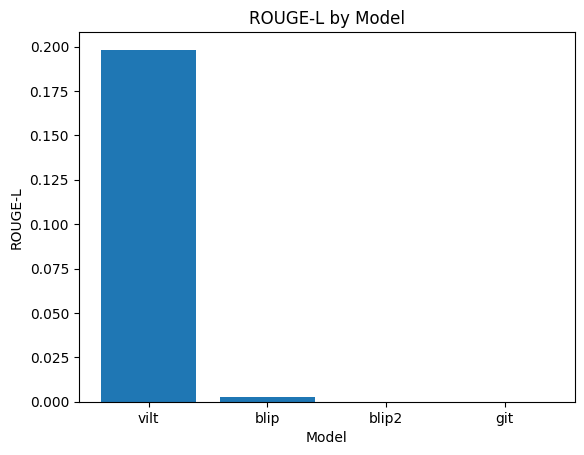

In [15]:
# Bar charts for BLEU and ROUGE-L
plt.figure()
plt.bar(summary_df["model"], summary_df["BLEU_avg"])
plt.title("Average BLEU by Model")
plt.xlabel("Model")
plt.ylabel("BLEU")

plt.figure()
plt.bar(summary_df["model"], summary_df["ROUGE_L"])
plt.title("ROUGE-L by Model")
plt.xlabel("Model")
plt.ylabel("ROUGE-L")

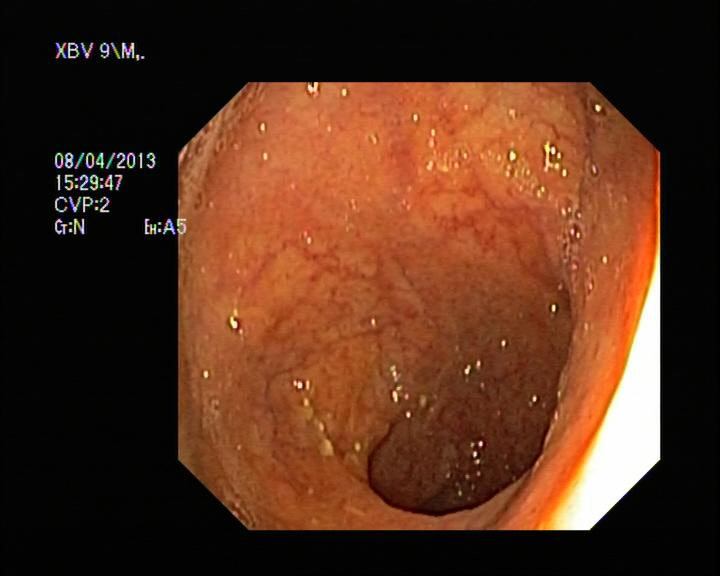

Image ID: cla820gl0s3nv071u4fgd7xgq
Q: Are there any abnormalities in the image? Check all that are present.
GT: ulcerative colitis

[blip] pred: are there any abnormalities in the image? check all that are present.. 5 | BLEU: 0.00
[blip2] pred: Are there any abnormalities in the image? Check all that are present.
 | BLEU: 0.00
[git] pred: question : are there any abnormalities in the image? check all that are present. answer : | BLEU: 0.00
[vilt] pred: yes | BLEU: 0.00


In [28]:
def show_side_by_side(detail_df, img_idx=0):
    """
    Shows the same (img, question) across all models with predictions.
    Assumes detail_df contains multiple models' rows for the same img_id/question.
    """
    # pick one (img_id, question) pair
    pivot_cols = ["img_id", "question"]
    grp = (detail_df.groupby(pivot_cols).size().reset_index(name="count")
                     .sort_values("count", ascending=False))
    if img_idx >= len(grp):
        print("Index out of range for grouped pairs; try a smaller img_idx.")
        return

    img_id = grp.iloc[img_idx]["img_id"]
    question = grp.iloc[img_idx]["question"]

    subset = detail_df[(detail_df["img_id"] == img_id) & (detail_df["question"] == question)]\
             .sort_values("model")

    if subset.empty:
        print("No rows found for the chosen pair.")
        return

    from IPython.display import display
    img_path = subset.iloc[0]["img_path"]
    display(Image.open(img_path).convert("RGB"))

    print(f"Image ID: {img_id}\nQ: {question}\nGT: {subset.iloc[0]['ground_truth']}\n")
    for _, r in subset.iterrows():
        print(f"[{r['model']}] pred: {r['predicted']} | BLEU: {r['bleu']:.2f}")

show_side_by_side(detail_df, img_idx=0)  # change idx to view others

In [39]:
# CONCLUSION 

# baseline off-the-shelf VQA models perform poorly on Kvasir-VQA

In [40]:
# Build a CNN-based baseline

In [29]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models, transforms

# Preprocessing for ResNet (standard ImageNet normalization)
cnn_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406],
                         std=[0.229,0.224,0.225])
])

In [51]:
# Defining CNN Based VQA Model

In [30]:
class CNNVQABaseline(nn.Module):
    def __init__(self, num_answers, embed_dim=256, hidden_dim=256):
        super().__init__()
        # Pretrained ResNet backbone
        self.resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet.fc = nn.Identity()  # take features before final FC
        img_dim = 2048

        # Text embedding (simple GRU)
        self.word_emb = nn.Embedding(10000, embed_dim)  # vocab size ~10k
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        # Fusion + classifier
        fusion_dim = img_dim + hidden_dim
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Linear(512, num_answers)
        )

    def forward(self, images, questions):
        # images: [B,3,224,224]
        img_feat = self.resnet(images)  # [B, 2048]

        # questions: [B, T]
        q_emb = self.word_emb(questions)
        _, h = self.gru(q_emb) 
        q_feat = h.squeeze(0)   

        fused = torch.cat([img_feat, q_feat], dim=1)
        out = self.classifier(fused)
        return out

In [31]:
from collections import Counter

# Choose top 100 answers as the label space
N_ANSWERS = 100
answer_counts = Counter(df_uc["answer"].astype(str))
top_answers = [a for a, _ in answer_counts.most_common(N_ANSWERS)]
ans2idx = {a:i for i,a in enumerate(top_answers)}
idx2ans = {i:a for a,i in ans2idx.items()}

def encode_answer(ans):
    return ans2idx.get(ans, None) 


In [32]:
class UC_VQADataset(torch.utils.data.Dataset):
    def __init__(self, df, transform, ans2idx, max_len=16):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.ans2idx = ans2idx
        self.max_len = max_len

        # simple tokenizer (whitespace split)
        self.word2idx = {"<pad>":0, "<unk>":1}
        self.idx2word = {0:"<pad>", 1:"<unk>"}
        self.vocab_size = 2

    def tokenize(self, text):
        tokens = text.lower().split()
        ids = []
        for t in tokens:
            if t not in self.word2idx:
                self.word2idx[t] = self.vocab_size
                self.idx2word[self.vocab_size] = t
                self.vocab_size += 1
            ids.append(self.word2idx[t])
        return ids

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row["img_path"]).convert("RGB")
        image = self.transform(image)

        q_ids = self.tokenize(str(row["question"]))
        if len(q_ids) < self.max_len:
            q_ids += [0]*(self.max_len - len(q_ids))
        else:
            q_ids = q_ids[:self.max_len]
        q_ids = torch.tensor(q_ids)

        ans = encode_answer(str(row["answer"]))
        return image, q_ids, ans

In [25]:
# Training Loop

In [33]:
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from torchvision import models
import pandas as pd
import os

# Train/test split for fair CNN eval
# Ensure df_uc/all_df exist; set TEST_FRAC > 0 to avoid evaluating on the training set
TEST_FRAC = 0.15

if "df_uc" not in globals():
    df_uc = pd.read_csv("./metadata.csv")
    if "source" in df_uc.columns:
        df_uc = df_uc[df_uc["source"] == "Ulcerative Colitis"]
    df_uc = df_uc.reset_index(drop=True)

all_df = df_uc[df_uc["answer"].isin(top_answers)].reset_index(drop=True)

if TEST_FRAC > 0:
    train_df = all_df.sample(frac=1-TEST_FRAC, random_state=SEED)
    test_df  = all_df.drop(train_df.index).reset_index(drop=True)
    train_df = train_df.reset_index(drop=True)
else:
    train_df = all_df
    test_df  = all_df.copy()

train_ds = UC_VQADataset(train_df, cnn_transform, ans2idx)
test_ds  = UC_VQADataset(test_df,  cnn_transform, ans2idx)

def safe_collate(batch):
    imgs, qs, ans = [], [], []
    for b in batch:
        try:
            x_img, x_q, x_a = b
            if x_a is None:
                continue
            imgs.append(x_img)
            qs.append(x_q)
            ans.append(x_a)
        except Exception:
            # skip any sample that errors in __getitem__
            continue
    if len(imgs) == 0:
        # return empty tensors so the training loop can skip
        return (torch.empty(0, 3, 224, 224), torch.empty(0, 16, dtype=torch.long), torch.empty(0, dtype=torch.long))
    return (torch.stack(imgs, 0),
            torch.stack(qs,   0).long(),
            torch.tensor(ans, dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=safe_collate)
test_loader  = DataLoader(test_ds,  batch_size=64, shuffle=False, collate_fn=safe_collate)

class CNNVQABaseline(nn.Module):
    def __init__(self, num_answers, embed_dim=256, hidden_dim=256):
        super().__init__()
        try:
            weights = models.ResNet50_Weights.IMAGENET1K_V1
            self.resnet = models.resnet50(weights=weights)
        except Exception:
            self.resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet.fc = nn.Identity()
        img_dim = 2048

        self.word_emb = nn.Embedding(10000, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        fusion_dim = img_dim + hidden_dim
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Linear(512, num_answers)
        )

    def forward(self, images, questions):
        img_feat = self.resnet(images)
        q_emb = self.word_emb(questions)
        _, h = self.gru(q_emb)
        q_feat = h.squeeze(0)
        fused = torch.cat([img_feat, q_feat], dim=1)
        return self.classifier(fused)

model_cnn = CNNVQABaseline(num_answers=N_ANSWERS).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-4)

torch.set_grad_enabled(True)

for epoch in range(2):
    model_cnn.train()
    total_loss = 0.0
    num_batches = 0

    for imgs, qs, ans in train_loader:
        if imgs.shape[0] == 0:
            continue
        imgs, qs, ans = imgs.to(DEVICE), qs.to(DEVICE), ans.to(DEVICE)

        out = model_cnn(imgs, qs)
        loss = criterion(out, ans)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_loss = (total_loss / max(1, num_batches))
    print(f"Epoch {epoch+1}: Train loss = {avg_loss:.4f}")


Epoch 1: Train loss = 0.9620
Epoch 2: Train loss = 0.3227


In [34]:
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
from torchvision import models
import time

# Use full UC subset; evaluate on all rows (TEST_FRAC=0.0)
TEST_FRAC = 0.0
all_df = df_uc[df_uc["answer"].isin(top_answers)].reset_index(drop=True)
train_df = all_df.sample(frac=1-TEST_FRAC, random_state=SEED)
test_df  = all_df.copy() if TEST_FRAC == 0 else all_df.drop(train_df.index).reset_index(drop=True)
train_df = train_df.reset_index(drop=True)

train_ds = UC_VQADataset(train_df, cnn_transform, ans2idx)
test_ds  = UC_VQADataset(test_df,  cnn_transform, ans2idx)

def safe_collate(batch):
    imgs, qs, ans = [], [], []
    for b in batch:
        try:
            x_img, x_q, x_a = b
            if x_a is None:
                continue
            imgs.append(x_img)
            qs.append(x_q)
            ans.append(x_a)
        except Exception:
            # skip any sample that errors in __getitem__
            continue
    if len(imgs) == 0:
        # return empty tensors so the training loop can skip
        return (torch.empty(0, 3, 224, 224), torch.empty(0, 16, dtype=torch.long), torch.empty(0, dtype=torch.long))
    return (torch.stack(imgs, 0),
            torch.stack(qs,   0).long(),
            torch.tensor(ans, dtype=torch.long))

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True, collate_fn=safe_collate)

class CNNVQABaseline(nn.Module):
    def __init__(self, num_answers, embed_dim=256, hidden_dim=256):
        super().__init__()
        # Try new torchvision weights API first, fall back to old string if needed
        try:
            weights = models.ResNet50_Weights.IMAGENET1K_V1
            self.resnet = models.resnet50(weights=weights)
        except Exception:
            self.resnet = models.resnet50(weights="IMAGENET1K_V1")
        self.resnet.fc = nn.Identity()   # take penultimate features
        img_dim = 2048

        self.word_emb = nn.Embedding(10000, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

        fusion_dim = img_dim + hidden_dim
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 512),
            nn.ReLU(),
            nn.Linear(512, num_answers)
        )

    def forward(self, images, questions):
        img_feat = self.resnet(images)               # [B, 2048]
        q_emb = self.word_emb(questions)             # [B, T, E]
        _, h = self.gru(q_emb)                       # h: [1, B, H]
        q_feat = h.squeeze(0)                        # [B, H]
        fused = torch.cat([img_feat, q_feat], dim=1) # [B, 2048+H]
        return self.classifier(fused)                # [B, num_answers]

model_cnn = CNNVQABaseline(num_answers=N_ANSWERS).to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-4)

# Ensure gradients are enabled (in case a prior cell disabled them globally)
torch.set_grad_enabled(True)

for epoch in range(2):
    model_cnn.train()
    total_loss = 0.0
    num_batches = 0

    for imgs, qs, ans in train_loader:
        if imgs.shape[0] == 0:            # empty batch (all dropped) → skip
            continue
        imgs, qs, ans = imgs.to(DEVICE), qs.to(DEVICE), ans.to(DEVICE)

        out = model_cnn(imgs, qs)
        loss = criterion(out, ans)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        num_batches += 1

    avg_loss = (total_loss / max(1, num_batches))
    print(f"Epoch {epoch+1}: Train loss = {avg_loss:.4f}")

model_cnn.eval()
all_preds, all_refs = [], []

# Evaluate on held-out test split for apples-to-apples comparison
infer_loader = test_loader
start = time.time()

with torch.no_grad():
    for imgs, qs, ans in infer_loader:
        if imgs.shape[0] == 0:
            continue
        imgs, qs = imgs.to(DEVICE), qs.to(DEVICE)
        out = model_cnn(imgs, qs)
        pred_idx = torch.argmax(out, dim=1).cpu().tolist()
        preds = [idx2ans[i] for i in pred_idx]
        refs  = [idx2ans[a.item()] if a.item() in idx2ans else "" for a in ans]

        all_preds.extend(preds)
        all_refs.extend(refs)

bleus  = [compute_bleu(p, r) for p, r in zip(all_preds, all_refs)]
bleu_cnn  = sum(bleus)/len(bleus) if bleus else 0.0
rouge_cnn = compute_rougeL(all_preds, all_refs) if all_preds else 0.0
n_cnn_eval = len(all_preds)
cnn_time_sec = time.time() - start
cnn_tpex = cnn_time_sec / max(1, n_cnn_eval)
print(f"CNN baseline → BLEU: {bleu_cnn:.3f}, ROUGE-L: {rouge_cnn:.3f} on {n_cnn_eval} examples (time_sec={cnn_time_sec:.1f}, sec/example={cnn_tpex:.4f})")


Epoch 1: Train loss = 0.8674
Epoch 2: Train loss = 0.3160
CNN baseline → BLEU: 0.058, ROUGE-L: 0.305 on 2526 examples (time_sec=10.6, sec/example=0.0042)


In [36]:
# Merging Results 

In [35]:
# Merge with CNN baseline metrics
import pandas as pd
from pathlib import Path
import numpy as np

# 1. Load summary if not already in memory
if 'summary_df' not in globals():
    phase3_summary_path = Path("phase3_results/summary_uc_phase3.csv")
    if phase3_summary_path.exists():
        summary_df = pd.read_csv(phase3_summary_path)
    else:
        summary_df = pd.DataFrame(columns=["model","n_examples","BLEU_avg","ROUGE_L","time_sec","time_per_example_sec"])

# 2) Build combined table
combined = summary_df[["model","n_examples","BLEU_avg","ROUGE_L"]].copy() if not summary_df.empty else pd.DataFrame(columns=["model","n_examples","BLEU_avg","ROUGE_L"])

# CNN metrics from your previous cell (bleu_cnn, rouge_cnn, n_cnn_eval)
cnn_row = {
    "model": "cnn_baseline",
    "n_examples": n_cnn_eval if 'n_cnn_eval' in globals() else (len(all_preds) if 'all_preds' in globals() else np.nan),
    "BLEU_avg": float(bleu_cnn) if 'bleu_cnn' in globals() else np.nan,
    "ROUGE_L": float(rouge_cnn) if 'rouge_cnn' in globals() else np.nan,
    "time_sec": cnn_time_sec if 'cnn_time_sec' in globals() else np.nan,
    "time_per_example_sec": cnn_tpex if 'cnn_tpex' in globals() else np.nan,
}
# Replace/add CNN row in summary and persist
if not summary_df.empty:
    summary_df = summary_df[summary_df["model"] != "cnn_baseline"]
summary_df = pd.concat([summary_df, pd.DataFrame([cnn_row])], ignore_index=True)
summary_path = Path("phase3_results/summary_uc_phase3.csv")
summary_df.to_csv(summary_path, index=False)

combined = summary_df[["model","n_examples","BLEU_avg","ROUGE_L"]].copy()

# 3. Sort by BLEU (desc) and show
combined = combined.sort_values("BLEU_avg", ascending=False).reset_index(drop=True)
print("=== CNN vs Transformer on UC subset ===")
display(combined)

# 4. Simple improvement readout vs CNN
if "cnn_baseline" in combined["model"].values:
    base_bleu = combined.loc[combined["model"]=="cnn_baseline","BLEU_avg"].values[0]
    base_rouge = combined.loc[combined["model"]=="cnn_baseline","ROUGE_L"].values[0]
    # pick the best non-CNN model by BLEU
    non_cnn = combined[combined["model"]!="cnn_baseline"]
    if not non_cnn.empty:
        leader = non_cnn.iloc[0]
        abs_bleu_gain = leader["BLEU_avg"] - base_bleu
        abs_rouge_gain = leader["ROUGE_L"] - base_rouge
        print(f"\nBest transformer by BLEU: {leader['model']}")
        print(f"Absolute BLEU gain vs CNN: {abs_bleu_gain:.4f}")
        print(f"Absolute ROUGE-L gain vs CNN: {abs_rouge_gain:.4f}")
        if base_bleu > 0:
            rel_bleu = 100.0 * abs_bleu_gain / base_bleu
            print(f"Relative BLEU improvement: {rel_bleu:.1f}%")
        else:
            print("Relative BLEU improvement undefined (CNN BLEU == 0). Reporting absolute gain instead.")


=== CNN vs Transformer on UC subset ===


,model,n_examples,BLEU_avg,ROUGE_L
0,cnn_baseline,2526,0.058481,0.304536
1,vilt,16890,0.031478,0.198241
2,blip,16890,0.000335,0.002885
3,blip2,16890,0.000007,0.000044
4,git,16890,0.000004,0.000036



Best transformer by BLEU: vilt
Absolute BLEU gain vs CNN: -0.0270
Absolute ROUGE-L gain vs CNN: -0.1063
Relative BLEU improvement: -46.2%


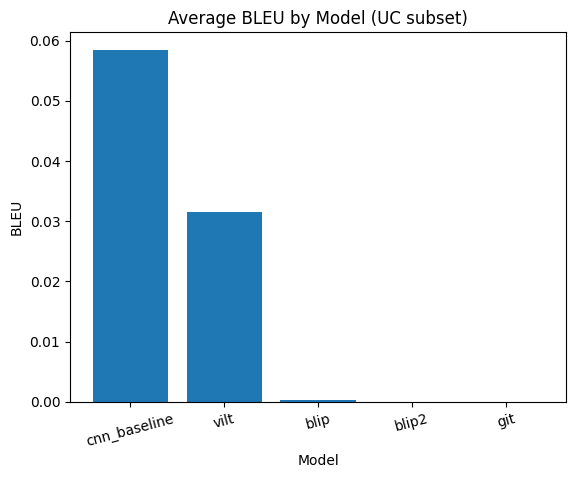

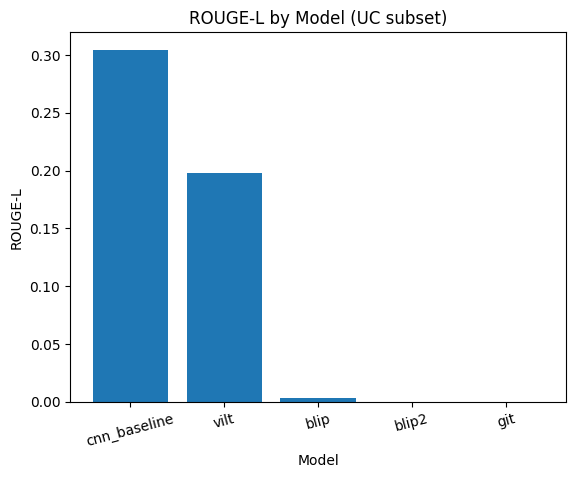

In [36]:
import matplotlib.pyplot as plt

# Guard against empty frame
if not combined.empty:
    plt.figure()
    plt.bar(combined["model"], combined["BLEU_avg"])
    plt.title("Average BLEU by Model (UC subset)")
    plt.xlabel("Model")
    plt.ylabel("BLEU")
    plt.xticks(rotation=15)

    plt.figure()
    plt.bar(combined["model"], combined["ROUGE_L"])
    plt.title("ROUGE-L by Model (UC subset)")
    plt.xlabel("Model")
    plt.ylabel("ROUGE-L")
    plt.xticks(rotation=15)
else:
    print("No results to plot. Make sure Phase 3 summary and CNN metrics exist.")